# ConvexAD: Geometrically regularized Automatic differentiation model for BCDI phase retrieval 

Author: **Matteo Masto** 


Post-Doctoral fellow at CEA Grenoble and ESRF

In [20]:
import glob, site, ctypes

for sp in site.getsitepackages():
    for lib in glob.glob(f"{sp}/nvidia/*/lib/*.so*"):
        try:
            ctypes.CDLL(lib)
        except OSError:
            pass

import tensorflow as tf
print(tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

2.21.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
import os
import tensorflow as tf
import numpy as np
import scipy
from scipy.fft import fftshift, ifftshift, fftn
import pylab as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import hdf5plugin
import h5py

import convex_ad
from convex_ad.core import *
from convex_ad.viz import *
from convex_ad.losses import *
from convex_ad.utils import *

from tensorflow.signal import fft3d, ifft3d, ifftshift, fftshift
import colorcet as cc


# Load and visualize the data

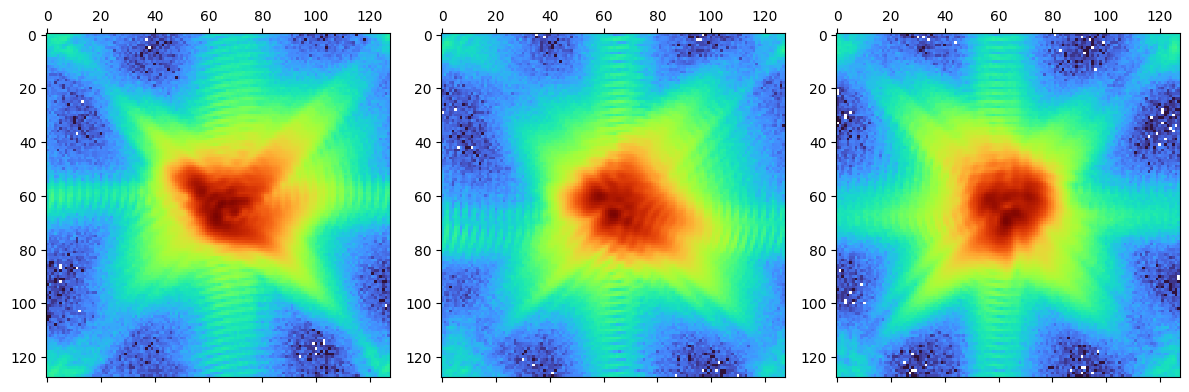

In [22]:
Iobs = np.load("data_prova.npz")["I"]
plot_3D_projections(Iobs, cmap = 'turbo')

# Define the model

`bs` is the batch_size, i.e. the number of objects automatically optimized in parallel by Tensorflow. Carefull not to saturate the memory. For large datasets it's better to reduce `bs` to 1 or 2 (e.g. 2x200x200x200)
`phase_type`: can be either `grid` for generic tensor (advised for large data or not too hard PR); `phasor` a (sin, cos) parametrization of the phase; `displacement` for a parametrization of the displacement field parallel to the given `[hkl]` node. The phase is calculated as $ (c(x,y,z), s(x,y,z)) = (cos(\phi), sin(\phi))$ where $ \phi(x,y,z) = |\mathbf{G_hkl}| u_{\text{parallel}}(x,y,z)$ and then   takes more memory but behaves better in the optimization.

`N` is the number of *half-space* vectors used to define the support. For each of them the length *d* and the orientation vector *n* in S^2 space is optimized. A plane is built at distance *d* from the origin and the support is found by the intersection of all the planes. `eps` is a parameter of the sigmoid that defines the *resolution* of the reconstruction. Higher `eps` means lower resolution and vice versa. `size_factor` is a parameter that is used to tune the support extent during the initialization.

`grid_shape` is by default `(Iobs.shape[0]//2, Iobs.shape[1]//2, Iobs.shape[2]//2)` as it assumes the oversampling condition satisfied. It can be be passed for custom shapes. 

In [23]:
bs = 32

model = convex_ad.PhaseRetrievalModel(
    Iobs,
    bs,
    phase_type='displacement',                                                  
    support_kwargs={'N':64, 'eps':0.6, 'size_factor': 5.5},
    phasor_kwargs = {'hkl': [1,1,1]}
)

support, amp, phase = model(Iobs)

# Optimizer hyperparameters

`init_lr` is the initial learning rate. It controls how fast the algorithms is driven towards the minimum. Typical values are in the range (0.5 - 0.01). The chosen optimizer is `ADAM` as it has proven best performance as compared to others. 

In [24]:
init_lr = 0.05

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=init_lr,
    decay_steps=500,       
    decay_rate=0.9,        
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    beta_1=0.9,            
    beta_2=0.98,           
    epsilon=1e-6,          
    amsgrad=True,         
)

_ = model(None)
optimizer.apply_gradients([(tf.zeros_like(v), v) for v in model.trainable_variables])


<Variable path=adam/iteration, shape=(), dtype=int64, value=1>

# Initialize the coefficient

- `alpha_small` is a coefficient that penalizes large supports. Usually between 0.0 and 0.01. It's usually not needed, one can leave it to 0.0
- `beta_tv` is a coefficient that forces the object's phase to be smooth. Better to start with 0.0 and in case regulate later. 

In [25]:
alpha_small = 0.0
beta_tv = 0.0
noise_scale = 0.0

In [26]:
from tensorflow.signal import fft3d, ifft3d, fftshift, ifftshift

fourier = fourier_loss(support, amp, phase, Iobs, metric = 'mae').numpy()
alpha_small = alpha_small*fourier/small_support(support).numpy()  
beta_tv = beta_tv*fourier/tv_loss_phase(phase).numpy()  


In [27]:
fourier = fourier_loss(support, amp, phase, Iobs).numpy()

print('Fourier loss: ', np.mean(fourier))
print('Small support loss: ', np.mean(alpha_small * small_support(support).numpy()))
print('TV phase loss: ', np.mean(beta_tv * tv_loss_phase(phase).numpy()))


Fourier loss:  1.4186532
Small support loss:  0.0
TV phase loss:  0.0


# Run the optimization 

for `'mae'` loss when the displayed loss value reaches ~ 0.1, a good enough convergence has been attained. 

In [28]:
n_steps = 5000

for step in range(n_steps):

    loss = convex_ad.train_step(
        model,
        Iobs,
        optimizer,
        alpha_small=alpha_small,
        beta_tv=beta_tv,
        noise_scale=noise_scale,
        metric = 'mae' # 'poisson' is the other option for Poisson Negative LLK
    )

    if step % 50 == 0:
        print(f"Step {step:05d} | Loss: {np.min(loss.numpy()):.4f} ")

Step 00000 | Loss: 1.4107 
Step 00050 | Loss: 0.4089 
Step 00100 | Loss: 0.3452 
Step 00150 | Loss: 0.2975 
Step 00200 | Loss: 0.2746 
Step 00250 | Loss: 0.2671 
Step 00300 | Loss: 0.2556 
Step 00350 | Loss: 0.2406 
Step 00400 | Loss: 0.2276 
Step 00450 | Loss: 0.2224 
Step 00500 | Loss: 0.2145 
Step 00550 | Loss: 0.2077 
Step 00600 | Loss: 0.2049 
Step 00650 | Loss: 0.2025 
Step 00700 | Loss: 0.2016 
Step 00750 | Loss: 0.1958 
Step 00800 | Loss: 0.1745 
Step 00850 | Loss: 0.1135 
Step 00900 | Loss: 0.1027 
Step 00950 | Loss: 0.0972 
Step 01000 | Loss: 0.0769 
Step 01050 | Loss: 0.0712 
Step 01100 | Loss: 0.0681 
Step 01150 | Loss: 0.0728 
Step 01200 | Loss: 0.0661 
Step 01250 | Loss: 0.0664 
Step 01300 | Loss: 0.0666 
Step 01350 | Loss: 0.0674 
Step 01400 | Loss: 0.0656 
Step 01450 | Loss: 0.0667 
Step 01500 | Loss: 0.0640 



KeyboardInterrupt



# Visualize the results

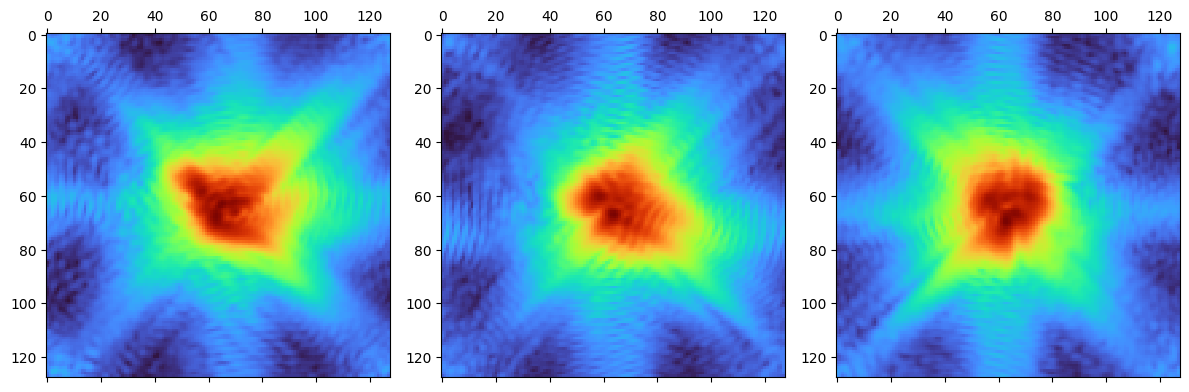

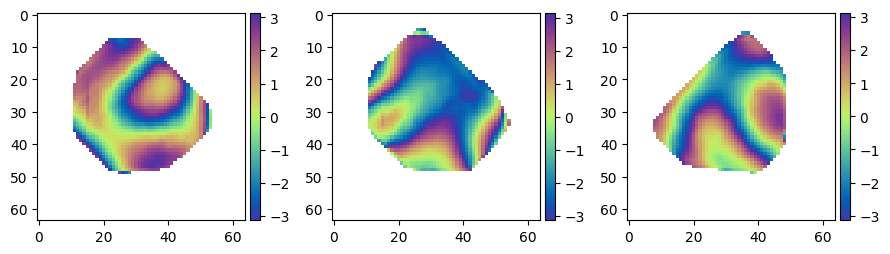

In [29]:
support, amplitude, phase = model()

idx = np.argmin(fourier_loss(support, amplitude, phase, Iobs).numpy())

support = support.numpy()[idx]
amplitude = amplitude.numpy()[idx]

if isinstance(phase, tuple):
    c, s = phase
    phase = np.arctan2(s.numpy()[idx], c.numpy()[idx])
else:
    phase = phase.numpy()[idx]

obj = amplitude * support * np.exp(1j * phase)

obj_shp = tf.shape(obj)
obs_shp = tf.shape(Iobs)

dD = obs_shp[0] - obj_shp[0]
dH = obs_shp[1] - obj_shp[1]
dW = obs_shp[2] - obj_shp[2]

pD0 = dD // 2; pD1 = dD - pD0
pH0 = dH // 2; pH1 = dH - pH0
pW0 = dW // 2; pW1 = dW - pW0

obj_p = tf.pad(obj, [[pD0,pD1],[pH0,pH1],[pW0,pW1]])

# --- FFT ---
Icalc = tf.abs(tf.signal.ifftshift(
    tf.signal.fft3d(tf.signal.fftshift(obj_p))
    
))**2

plot_3D_projections(Icalc, log_scale=True, cmap = 'turbo')
plot_2D_slices_middle_only_phase(obj, cmap = 'cet_CET_C9s_r', unwrap = False)

# Refine the object with Iobs

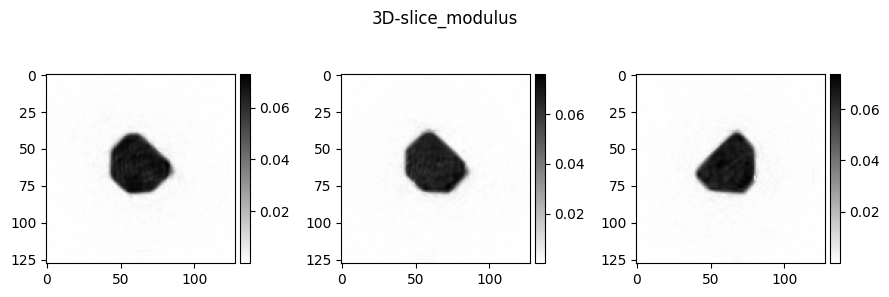

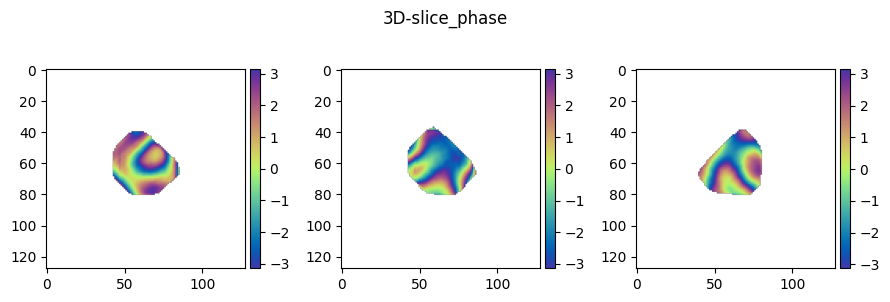

In [30]:
final_obj = project(obj_p, Iobs)
plot_2D_slices_middle_only_module(final_obj, fig_title='3D-slice_modulus')
plot_2D_slices_middle_only_phase(final_obj, fig_title='3D-slice_phase',  cmap = 'cet_CET_C9s_r', unwrap = False)

# Ground truth object

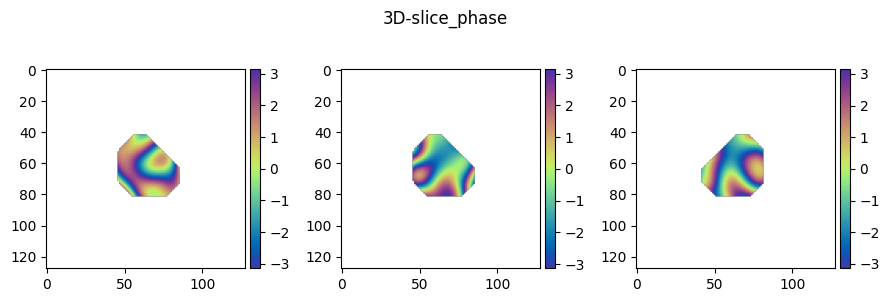

In [31]:
obj_true = np.load("data_prova.npz")['obj']
plot_2D_slices_middle_only_phase(obj_true, fig_title='3D-slice_phase',  cmap = 'cet_CET_C9s_r', unwrap = False)

# Save trainable variables for further convexAD optimization

In [110]:
save_model_npz(model, "pr_model_data_prova.npz")
